# ⚛️ Qiskit Discussion Section
## Quantum Computing — Interactive Lab Notebook

---

Welcome! This notebook is structured into **three sections**:

| Section | Topic |
|---------|-------|
| **§1** | Intro to Qiskit · Creating quantum states · Bloch sphere · Quantum Teleportation |
| **§2** | Simon's Algorithm (with linear algebra recovery) |
| **§3** | IBM Quantum Simulator — noise models & real hardware |

### Setup — run this first!
```bash
pip install qiskit qiskit-aer qiskit-ibm-runtime matplotlib pylatexenc
```

In [100]:
# ── Global imports (run this cell first!) ──────────────────────────────────
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.visualization import plot_bloch_multivector, plot_histogram
from qiskit.quantum_info import Statevector, DensityMatrix, state_fidelity
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error

import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("✅ All imports successful! Ready to do quantum computing.")

✅ All imports successful! Ready to do quantum computing.


---
# Section 1 — Introduction to Qiskit
## 1.1 Creating Quantum States

A **qubit** is the quantum analogue of a classical bit. Unlike a bit (which is either 0 or 1), a qubit can be in a **superposition**:

$$|\psi\rangle = \alpha|0\rangle + \beta|1\rangle \quad \text{where} \quad |\alpha|^2 + |\beta|^2 = 1$$

In Qiskit, qubits always start in the ground state $|0\rangle$. We apply **gates** (unitary matrices) to rotate the state.

### Key gates

| Gate | Symbol | Effect |
|------|--------|--------|
| Hadamard | `h` | $\vert 0\rangle \to \frac{\vert 0\rangle+\vert 1\rangle}{\sqrt{2}}$ — superposition |
| Pauli-X  | `x` | $\vert 0\rangle \leftrightarrow \vert 1\rangle$ — quantum NOT |
| Pauli-Z  | `z` | $\vert 1\rangle \to -\vert 1\rangle$ — phase flip |
| CNOT     | `cx` | Flips target if control is $\vert 1\rangle$ — entanglement |
| $R_y(\theta)$ | `ry` | Rotation by angle $\theta$ around the Y-axis of the Bloch sphere |

In [101]:
# ── 1. The ground state |0⟩ ────────────────────────────────────────────────
# Every qubit starts here by default.
qc_zero = QuantumCircuit(1)
sv_zero = Statevector(qc_zero)
print(f"Ground state |0⟩:  {sv_zero}")
# [1+0j, 0+0j] → probability 1 of measuring 0

# ── 2. Superposition |+⟩ = H|0⟩ ───────────────────────────────────────────
# The Hadamard gate rotates |0⟩ to the equator of the Bloch sphere.
qc_plus = QuantumCircuit(1)
qc_plus.h(0)            # Apply Hadamard to qubit 0
sv_plus = Statevector(qc_plus)
print(f"Plus state  |+⟩:  {sv_plus}")
# [0.707+0j, 0.707+0j] → 50% chance of 0, 50% chance of 1

# ── 3. Excited state |1⟩ ──────────────────────────────────────────────────
qc_one = QuantumCircuit(1)
qc_one.x(0)             # Pauli-X (NOT gate)
sv_one = Statevector(qc_one)
print(f"Excited state |1⟩: {sv_one}")

# ── 4. Arbitrary state with Ry(θ) ──────────────────────────────────────────
theta = np.pi / 3       # 60 degrees
qc_rot = QuantumCircuit(1)
qc_rot.ry(theta, 0)
sv_rot = Statevector(qc_rot)
print(f"Rotated state Ry(π/3)|0⟩: {sv_rot}")
print(f"  Prob(|0⟩) = {abs(sv_rot[0])**2:.3f},  Prob(|1⟩) = {abs(sv_rot[1])**2:.3f}")

Ground state |0⟩:  Statevector([1.+0.j, 0.+0.j],
            dims=(2,))
Plus state  |+⟩:  Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))
Excited state |1⟩: Statevector([0.+0.j, 1.+0.j],
            dims=(2,))
Rotated state Ry(π/3)|0⟩: Statevector([0.8660254+0.j, 0.5      +0.j],
            dims=(2,))
  Prob(|0⟩) = 0.750,  Prob(|1⟩) = 0.250


## 1.2 Visualising States — The Bloch Sphere

Every single-qubit state $|\psi\rangle = \cos\frac{\theta}{2}|0\rangle + e^{i\phi}\sin\frac{\theta}{2}|1\rangle$ maps to a **point on a unit sphere**:

- **North pole** = $|0\rangle$
- **South pole** = $|1\rangle$  
- **Equator** = equal superpositions (e.g. $|+\rangle$, $|-\rangle$, $|i\rangle$)

The `plot_bloch_multivector` function renders this for any statevector.

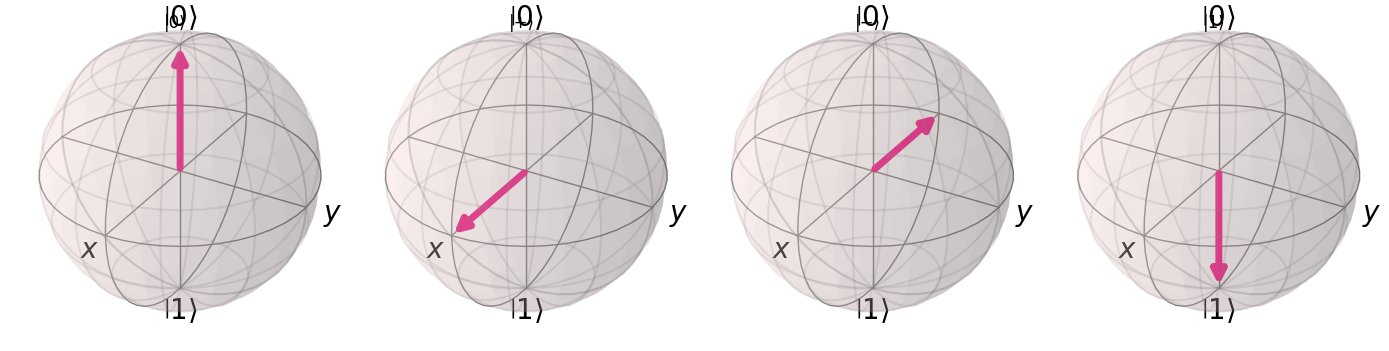

In [102]:
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization.bloch import Bloch
import numpy as np

# ── Convert statevector → Bloch vector ─────────────────────
def to_bloch(sv):
    a, b = sv.data
    return [
        2 * np.real(np.conj(a) * b),
        2 * np.imag(np.conj(a) * b),
        np.abs(a)**2 - np.abs(b)**2
    ]

# ── Build states ───────────────────────────────────────────
states = {}

qc = QuantumCircuit(1)
states['|0⟩'] = Statevector(qc)

qc = QuantumCircuit(1)
qc.h(0)
states['|+⟩'] = Statevector(qc)

qc = QuantumCircuit(1)
qc.h(0)
qc.z(0)
states['|−⟩'] = Statevector(qc)

qc = QuantumCircuit(1)
qc.x(0)
states['|1⟩'] = Statevector(qc)

# ── Plot side-by-side Bloch spheres ────────────────────────
fig = plt.figure(figsize=(14, 4))
axes = [fig.add_subplot(1, 4, i+1, projection='3d') for i in range(4)]

for ax, (label, sv) in zip(axes, states.items()):
    bloch = Bloch(axes=ax)
    bloch.add_vectors(to_bloch(sv))  # ← only supported method
    bloch.render()
    ax.set_title(label)

plt.tight_layout()
plt.show()

## 1.3 Entanglement — The Bell State

A **Bell state** is a maximally entangled two-qubit state. The canonical one is:

$$|\Phi^+\rangle = \frac{|00\rangle + |11\rangle}{\sqrt{2}}$$

Once entangled, measuring one qubit instantly determines the other — regardless of distance. This is the resource that powers teleportation.

**Recipe:** Apply $H$ to qubit 0, then $CNOT$ with qubit 0 as control and qubit 1 as target.

In [103]:
# ── Create and inspect the Bell state |Φ+⟩ ─────────────────────────────────
qc_bell = QuantumCircuit(2, name='Bell |Φ+⟩')
qc_bell.h(0)       # Step 1: Superpose qubit 0
qc_bell.cx(0, 1)   # Step 2: Entangle qubits 0 and 1

# Draw the circuit
print("Circuit:")
print(qc_bell.draw('text'))

# Inspect the state vector
sv_bell = Statevector(qc_bell)
print(f"\nStatevector: {sv_bell}")
print("→ Amplitudes: 1/√2 on |00⟩ and |11⟩, zero on |01⟩ and |10⟩")

# Simulate 1000 measurements
qc_bell_m = qc_bell.copy()
qc_bell_m.measure_all()

sim = AerSimulator()
result = sim.run(qc_bell_m, shots=1000).result()
counts = result.get_counts()

print(f"\nMeasurement results (1000 shots): {counts}")
print("→ Only |00⟩ and |11⟩ appear — they're perfectly correlated!")

fig = plot_histogram(counts)
fig.suptitle('Bell State Measurement Outcomes', fontsize=13)
plt.show()

Circuit:
     ┌───┐     
q_0: ┤ H ├──■──
     └───┘┌─┴─┐
q_1: ─────┤ X ├
          └───┘

Statevector: Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.70710678+0.j],
            dims=(2, 2))
→ Amplitudes: 1/√2 on |00⟩ and |11⟩, zero on |01⟩ and |10⟩

Measurement results (1000 shots): {'00': 496, '11': 504}
→ Only |00⟩ and |11⟩ appear — they're perfectly correlated!


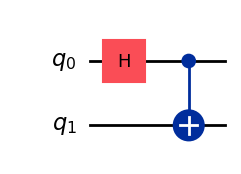

In [104]:
circuit_drawer(qc_bell, output='mpl')

---
## 1.4 Quantum Teleportation Protocol

Teleportation transfers an **unknown quantum state** from Alice to Bob using:
- 1 shared Bell pair (pre-distributed)
- 2 classical bits (sent over a normal channel)

> ⚠️ No information travels faster than light. The classical channel is the bottleneck.

### The Protocol

```
Alice has:  q0 = |ψ⟩ (unknown state to teleport)
            q1 = her half of the Bell pair
Bob has:    q2 = his half of the Bell pair

Step 1: Create Bell pair between q1 and q2
Step 2: Alice entangles her message qubit q0 with q1  →  CNOT(q0, q1)
Step 3: Alice applies H to q0                         →  H(q0)
Step 4: Alice measures q0 and q1  →  gets 2 classical bits (c0, c1)
Step 5: Alice sends c0, c1 to Bob over classical channel
Step 6: Bob applies corrections:
           if c1 == 1: apply X to q2
           if c0 == 1: apply Z to q2
Result: q2 is now in state |ψ⟩  ✓
```

> 🔒 **No-Cloning Theorem:** Alice's q0 is destroyed in the measurement. The state is *moved*, not copied.

In [105]:
import numpy as np
from qiskit import QuantumCircuit

def teleportation_circuit(theta=np.pi/3, phi=np.pi/4):
    # Create circuit with:
    # 3 quantum qubits → q0 (message), q1 (Alice), q2 (Bob)
    # 2 classical bits → to store Alice's measurement results
    qc = QuantumCircuit(3, 2)

    # ── Step 0: Prepare |ψ⟩ on q0 ───────────────────────────────
    # We create an arbitrary quantum state:
    # |ψ⟩ = cos(θ/2)|0⟩ + e^{iφ} sin(θ/2)|1⟩
    # This is the state we want to teleport

    qc.ry(theta, 0)   # rotate around Y → sets amplitude balance
    qc.rz(phi, 0)     # rotate around Z → sets phase
    qc.barrier()      # purely visual separator (no effect on physics)

    # 🔑 At this point:
    # q0 = |ψ⟩ (unknown state)
    # q1, q2 = |0⟩

    # ── Step 1: Create Bell pair between q1 and q2 ──────────────
    # This creates shared entanglement between Alice (q1) and Bob (q2)

    qc.h(1)           # puts q1 into superposition: (|0⟩ + |1⟩)/√2
    qc.cx(1, 2)       # entangles q1 and q2 → Bell state

    qc.barrier()

    # 🔑 Now:
    # (q1, q2) = (|00⟩ + |11⟩)/√2
    # This is the "quantum channel"

    # ── Step 2–3: Bell measurement on q0 and q1 ────────────────
    # Alice entangles her unknown state with her half of Bell pair

    qc.cx(0, 1)       # correlates q0 with q1
    qc.h(0)           # puts q0 into superposition

    qc.barrier()

    # 🔑 This transforms the system such that:
    # The original state |ψ⟩ is now encoded across q2,
    # but in a "scrambled" way depending on measurement outcomes

    # ── Step 4: Measure Alice's qubits ─────────────────────────
    # This collapses q0 and q1 into classical bits

    qc.measure(0, 0)  # result stored in classical bit c0
    qc.measure(1, 1)  # result stored in classical bit c1

    # 🔑 Important:
    # After measurement:
    # - q0 and q1 are destroyed (collapsed)
    # - we get 2 classical bits (00, 01, 10, 11)
    # - q2 now contains a *modified version* of |ψ⟩

    # ── Step 5–6: Bob applies corrections ─────────────────────
    # Based on Alice’s classical bits, Bob fixes his qubit

    # If c1 == 1 → apply X (bit flip)
    with qc.if_test((qc.clbits[1], 1)):
        qc.x(2)

    # If c0 == 1 → apply Z (phase flip)
    with qc.if_test((qc.clbits[0], 1)):
        qc.z(2)

    # 🔑 After these corrections:
    # q2 = original |ψ⟩
    # The state has been "teleported"

    return qc

In [106]:
from qiskit.visualization import circuit_drawer

qc = teleportation_circuit()

# Text (terminal-friendly)
print(qc.draw('text'))


     ┌─────────┐┌─────────┐ ░            ░      ┌───┐ ░ ┌─┐                   »
q_0: ┤ Ry(π/3) ├┤ Rz(π/4) ├─░────────────░───■──┤ H ├─░─┤M├───────────────────»
     └─────────┘└─────────┘ ░ ┌───┐      ░ ┌─┴─┐└───┘ ░ └╥┘┌─┐                »
q_1: ───────────────────────░─┤ H ├──■───░─┤ X ├──────░──╫─┤M├────────────────»
                            ░ └───┘┌─┴─┐ ░ └───┘      ░  ║ └╥┘  ┌──────  ┌───┐»
q_2: ───────────────────────░──────┤ X ├─░────────────░──╫──╫───┤ If-0  ─┤ X ├»
                            ░      └───┘ ░            ░  ║  ║   └──╥───  └───┘»
                                                         ║  ║ ┌────╨────┐     »
c: 2/════════════════════════════════════════════════════╩══╩═╡ c_1=0x1 ╞═════»
                                                         0  1 └─────────┘     »
«                                         
«q_0: ────────────────────────────────────
«                                         
«q_1: ────────────────────────────────────
«      ───────┐   ┌──────  ┌

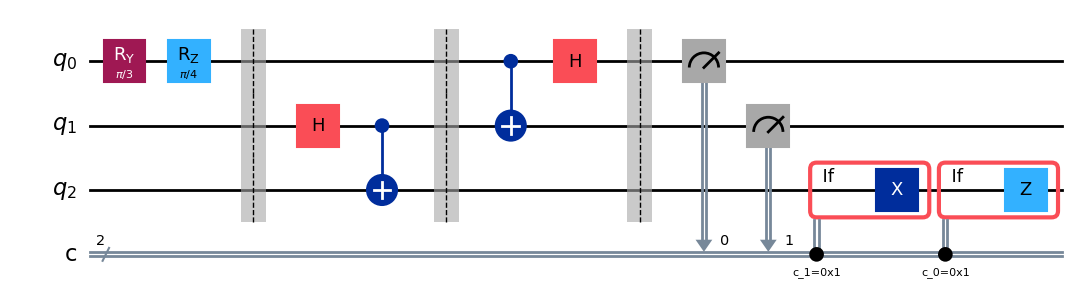

In [107]:
circuit_drawer(qc, output='mpl')

In [108]:
from qiskit_aer import Aer
from qiskit import transpile

sim = Aer.get_backend('aer_simulator')

qc = teleportation_circuit()

# Important: save final statevector of Bob’s qubit
qc.save_statevector()

compiled = transpile(qc, sim)
result = sim.run(compiled, shots=1024).result()

counts = result.get_counts()
print("Measurement counts (c1 c0):", counts)

Measurement counts (c1 c0): {'00': 273, '10': 245, '11': 261, '01': 245}


In [109]:
from qiskit.quantum_info import Statevector

# initial state of q0
qc_init = QuantumCircuit(1)
qc_init.ry(np.pi/3, 0)
qc_init.rz(np.pi/4, 0)

psi = Statevector(qc_init)

In [110]:
final_state = result.get_statevector(compiled)

In [111]:
from qiskit.quantum_info import partial_trace

rho_bob = partial_trace(final_state, [0, 1])  # keep q2

In [112]:
from qiskit.quantum_info import state_fidelity

fidelity = state_fidelity(rho_bob, psi)
print("Fidelity:", fidelity)

Fidelity: 0.9999999999999999


---
# Section 2 — Simon's Algorithm

## 2.1 The Problem

**Simon's Problem:** Given a black-box function $f: \{0,1\}^n \to \{0,1\}^n$ that is **two-to-one** with a hidden period $s \in \{0,1\}^n$:

$$f(x) = f(y) \iff x \oplus y \in \{0^n,\, s\}$$

Find $s$.

### Complexity comparison

| Approach | Query complexity |
|----------|------------------|
| Classical (best) | $O(2^{n/2})$ — birthday paradox |
| **Simon's quantum** | $O(n)$ — **exponential speedup!** |

## 2.2 How the Algorithm Works

1. Prepare $n$ input qubits and $n$ output qubits, all in $|0\rangle$
2. Apply Hadamard to input: creates uniform superposition over all $x$
3. Query the oracle: $|x\rangle|0\rangle \to |x\rangle|f(x)\rangle$
4. Apply Hadamard to input again
5. Measure the input register → get string $y$ such that $y \cdot s = 0 \pmod{2}$
6. Repeat $n-1$ times to get $n-1$ linearly independent equations
7. Solve over $GF(2)$ to recover $s$

## Step 1: Create Superposition

We start with all input qubits in the state:

$$
|0\rangle^{\otimes n}
$$

Applying Hadamard gates to each qubit gives:

$$
\frac{1}{\sqrt{2^n}} \sum_{x \in \{0,1\}^n} |x\rangle
$$

---

### Intuition

- The system is now in a **uniform superposition of all inputs**
- This allows us to evaluate the function on **all inputs at once**
- This is the source of **quantum parallelism**

---

### Important

At this stage:
- We have **no information about the hidden string s**
- We are only preparing the system

In [113]:
from qiskit import QuantumCircuit

n = 3  # number of input qubits

# Create circuit: n input qubits + n output qubits
qc = QuantumCircuit(2*n, n)

# Apply Hadamard to input register
qc.h(range(n))

# Visualize

qc_bell


qc.draw('text')

┌───┐
q_0: ┤ H ├
     ├───┤
q_1: ┤ H ├
     ├───┤
q_2: ┤ H ├
     └───┘
q_3: ─────
          
q_4: ─────
          
q_5: ─────
          
c: 3/═════

## Step 2: Apply the Oracle

We now apply the oracle \( U_f \), which computes:

$$
|x\rangle |0\rangle \;\rightarrow\; |x\rangle |f(x)\rangle
$$

---

### Key Property of the Function

The function satisfies:

$$
f(x) = f(x \oplus s)
$$

This means:
- Inputs come in pairs separated by the hidden string \( s \)
- The oracle maps both inputs in a pair to the same output

---

### What happens to the quantum state?

After applying the oracle, the system becomes:

$$
\frac{1}{\sqrt{2^n}} \sum_x |x\rangle |f(x)\rangle
$$

Because of the pairing structure, the state is now **entangled**.

---

### Intuition

- We still don’t know \( s \)
- But the structure of \( s \) is now encoded in the quantum state
- The next step (interference) will extract this structure

In [114]:
def simon_oracle(s):
    n = len(s)
    qc = QuantumCircuit(2*n)

    # Copy input → output
    for i in range(n):
        qc.cx(i, i + n)

    # Encode hidden string structure
    for i, bit in enumerate(s):
        if bit == '1':
            qc.cx(0, i + n)

    return qc

## Step 3: Apply Hadamard Again

We apply Hadamard gates again to the input register.

---

### Result

After this step, only bitstrings y remain such that:

$$
y \cdot s = 0 \; (\text{mod } 2)
$$

---

### What does this mean?

Each output y satisfies a linear constraint on s.

---

### Intuition

- Interference cancels out invalid solutions
- Only valid constraints survive

---

### Key Idea

Each run gives **one equation about s**, not s itself.

In [115]:
s = "110"  # hidden string

oracle = simon_oracle(s)

qc.compose(oracle, inplace=True)

qc.draw('text')

┌───┐                         
q_0: ┤ H ├──■──────────────■────■──
     ├───┤  │              │    │  
q_1: ┤ H ├──┼────■─────────┼────┼──
     ├───┤  │    │         │    │  
q_2: ┤ H ├──┼────┼────■────┼────┼──
     └───┘┌─┴─┐  │    │  ┌─┴─┐  │  
q_3: ─────┤ X ├──┼────┼──┤ X ├──┼──
          └───┘┌─┴─┐  │  └───┘┌─┴─┐
q_4: ──────────┤ X ├──┼───────┤ X ├
               └───┘┌─┴─┐     └───┘
q_5: ───────────────┤ X ├──────────
                    └───┘          
c: 3/══════════════════════════════

In [116]:
# Apply Hadamard again to input register
qc.h(range(n))

qc.draw('text')

┌───┐                              ┌───┐
q_0: ┤ H ├──■──────────────■─────────■──┤ H ├
     ├───┤  │       ┌───┐  │         │  └───┘
q_1: ┤ H ├──┼────■──┤ H ├──┼─────────┼───────
     ├───┤  │    │  └───┘  │  ┌───┐  │       
q_2: ┤ H ├──┼────┼────■────┼──┤ H ├──┼───────
     └───┘┌─┴─┐  │    │  ┌─┴─┐└───┘  │       
q_3: ─────┤ X ├──┼────┼──┤ X ├───────┼───────
          └───┘┌─┴─┐  │  └───┘     ┌─┴─┐     
q_4: ──────────┤ X ├──┼────────────┤ X ├─────
               └───┘┌─┴─┐          └───┘     
q_5: ───────────────┤ X ├────────────────────
                    └───┘                    
c: 3/════════════════════════════════════════

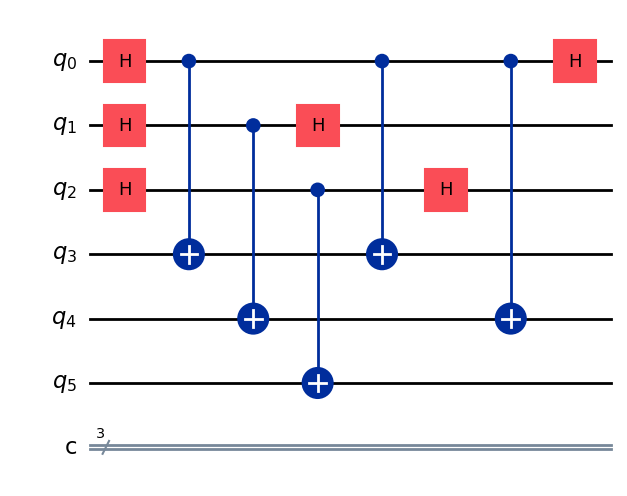

In [117]:
circuit_drawer(qc, output='mpl')

## Step 4: Measurement

We now measure the input register.

Each measurement gives a bitstring y such that:

$$
y \cdot s = 0 \; (\text{mod } 2)
$$

---

### What does this mean?

- Each measurement gives **one linear equation**
- We need multiple runs to recover s

---

### Example

If we measure:

    y = 101

This gives the equation:

    s1 + s3 = 0 (mod 2)

---

### Important

- One run is not enough
- We need multiple independent equations

---

### Big Picture

Measurement converts quantum information into classical constraints.

In [119]:
from qiskit_aer import Aer
from qiskit import transpile

# Measure input register
qc.measure(range(n), range(n))

# Run simulator
sim = Aer.get_backend('aer_simulator')

compiled = transpile(qc, sim)
result = sim.run(compiled, shots=20).result()

counts = result.get_counts()
print("Measurement results:")
print(counts)

Measurement results:
{'011': 2, '000': 2, '100': 7, '111': 9}


## Important Note: Bit Ordering in Qiskit

When we measure qubits in Qiskit, the output bitstrings are printed in **reverse order** compared to how we usually write vectors.

---

### What does this mean?

If Qiskit outputs:

    '011'

it actually corresponds to:

    y = 110

This is because Qiskit prints bits as:

    c(n-1) ... c(0)

- Leftmost bit → highest index  
- Rightmost bit → lowest index  

---

### Why is this important?

In Simon’s algorithm, we check:

$$
y \cdot s = 0 \; (\text{mod } 2)
$$

If we don’t reverse the bitstring, we may think a valid result is incorrect.

---

### Example

Qiskit output:

    '011'

Reverse it:

    '110'

Now compute:

$$
(1 \times 1) + (1 \times 1) + (0 \times 0) = 2 \equiv 0 \; (\text{mod } 2)
$$

So this is a **valid result**.

---

### Rule to follow

Always reverse before using the result:

```python
y = y[::-1]

In [120]:
ys = list(counts.keys())

# reverse bitstrings
ys = [y[::-1] for y in ys]

print("Processed y values:", ys)

Processed y values: ['110', '000', '001', '111']


## Solving for the Hidden String (Linear Algebra Step)

After running the circuit multiple times, we obtain several bitstrings:

    y1, y2, y3, ...

Each of these satisfies:

    y · s = 0 (mod 2)

---

### What does this mean?

Each bitstring gives one equation. For example:

    y = 101

gives:

    s1 + s3 = 0 (mod 2)

So every measurement gives a **linear constraint** on the unknown string s.

---

### Matrix Form

We can stack all these equations into a system:

    [ y1 ]      [ s1 ]
    [ y2 ]  ×   [ s2 ]   =   0   (mod 2)
    [ y3 ]      [ s3 ]

or more compactly:

    A · s = 0   (mod 2)

where:
- A is a matrix made from measured bitstrings
- s is the unknown vector

---

### How do we solve this?

We solve the system using **Gaussian elimination mod 2**.

The rules are:
- Addition is XOR
- 1 + 1 = 0
- Everything is modulo 2

---

### What are we looking for?

We are solving for a **non-zero vector s** such that:

    A · s = 0

This is called the **null space** of A.

---

### Important Note

- There may be multiple solutions
- The correct answer is the **non-zero solution**

---

### Big Idea

The quantum algorithm converts the problem into:

    "Find a vector in the null space of A"

This is why Simon’s algorithm is fundamentally a **linear algebra problem over mod 2**.

In [121]:
import numpy as np

def solve_mod2(ys):
    # convert strings → matrix
    A = np.array([[int(bit) for bit in y] for y in ys], dtype=int)

    # remove zero rows
    A = A[~np.all(A == 0, axis=1)]

    n = A.shape[1]

    # Gaussian elimination mod 2
    row = 0
    for col in range(n):
        # find pivot
        for r in range(row, len(A)):
            if A[r, col] == 1:
                A[[row, r]] = A[[r, row]]
                break
        else:
            continue

        # eliminate below
        for r in range(row + 1, len(A)):
            if A[r, col] == 1:
                A[r] ^= A[row]

        row += 1

    # back substitution (find null space vector)
    # brute force non-zero solution
    for i in range(1, 2**n):
        s = np.array(list(map(int, format(i, f'0{n}b'))))
        if np.all((A @ s) % 2 == 0):
            return s

    return None

In [122]:
s = solve_mod2(ys)
print("Recovered s:", s)

Recovered s: [1 1 0]


## Exercises and Extensions

### 1. Teleportation Without Classical Correction

Modify the quantum teleportation circuit by **removing the classical correction step** (the conditional X and Z gates).

- Run the circuit multiple times
- Observe the final state of Bob’s qubit

**Tasks:**
- Compare the final state with the original state
- Estimate how often teleportation succeeds
- Explain why the success rate is approximately 50%

---

### 2. Simon’s Algorithm — Different Hidden Strings

Run Simon’s algorithm for different hidden strings:

    s = 101
    s = 011
    s = 111

**Tasks:**
- Collect measurement results for each case
- Convert outputs into equations
- Solve for s using linear algebra (mod 2)

**Submission:**
- Show your measurement results
- Show your system of equations
- Show how you solved for s step-by-step

---

### 3. Explain Why It Works

For one of your runs of Simon’s algorithm:

- Take 2–3 measured bitstrings y
- Show explicitly that they satisfy:

      y · s = 0 (mod 2)

- Explain in words why only such y values appear
- Comment on how many times you have to measure the circuit to get sufficient information for the final result. How does this relate to algorithmic complexity?

---

### 4. Implement Another Algorithm / Protocol

Implement and conduct experiments on the following algorithm 

- Grover’s Algorithm (small example)
- Shor's Algorithm

**Tasks:**
- Implement the circuit in Qiskit
- Clearly document each step
- Explain what the algorithm is doing and why it works
- Experiments to convince yourself
---

### 5. Submission

- Submit a well documented LaTeX report
- This should include your own explanations of the algorithm and code snippets
- Submit ONE jupyter notebook with all thhe required code clearly commented
